# Extract microscopic diffusion parameters $(s, \epsilon)$ from single-fish data 
See Puri, et. al, PRL (2026) Supplementary Material (Sec. 3.2) for details of the fitting procedure 


In [38]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
import datetime
from scipy.special import comb
from itertools import combinations
from scipy.stats import multivariate_normal

import sys
sys.path.append('../..')
from codebase.subgroup_analysis import annotate_subgroups_framewise
from codebase.parameter_fitting import get_single_fish_dtheta_vs_dt, get_MSD_dtheta_vs_dt, fit_MSD_curve_linear_regime, fit_s_epsilon_jointly_bounded

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
data_path = '../../Data/groups_by_age/'
exp_details = pd.read_csv(data_path + 'exp_details.csv')
fish_ages = [2,4,6,8]
L = 50 # mm
fps = 121 # Hz
dt_for_v = 60 # frames skipped for velocity calculation, ~0.5s

mesoscopic_params_full_dataset = pd.read_csv("../../Results/mesoscopic_params_full_dataset.csv").to_numpy()

# Calculate $\Delta\theta (dt)$ for $N_G=1$ (single fish) in each experiment
Also compute fish velocity

In [5]:
T_max = 2 #s
dt_array = np.arange(int(0.01*fps), int(T_max*fps), 1) # in frames, 0.01s to 2s

dtheta_vs_dt_all_ages = {age: [] for age in fish_ages}
v_values_all_ages = {age: [] for age in fish_ages}

for j,age in enumerate(fish_ages):
    exp_list = np.flatnonzero(exp_details['fish_age']==age)
    dtheta_expwise = []
    v_expwise = []
    
    for exp in exp_list:
        fpath = f'{data_path}h5_files_cleaned/{exp_details["experiment"][exp]}.h5'
        f = h5py.File(fpath,'r')
        nfish = 4

        x = f['tracks'][:nfish,0,:,:] #array of shape (fish x nodes x frames)
        y = f['tracks'][:nfish,1,:,:]
        nose_x = (x[:,0,:] + x[:,1,:])/2 # avg L and R eye positions to get nose position
        nose_y = (y[:,0,:] + y[:,1,:])/2

        # calculate linear velocity for all fish & frames
        vx = (nose_x[:,dt_for_v:] - nose_x[:,:-dt_for_v])/dt_for_v * fps
        vy = (nose_y[:,dt_for_v:] - nose_y[:,:-dt_for_v])/dt_for_v * fps
        v_expwise.append(np.sqrt(vx**2 + vy**2).reshape(-1))

        # heading angles by calculating angle between nose and mid-bladder (node index 3)
        # mid-bladder is a more stable reference point than tail 
        head_angles = np.arctan2(nose_y - y[:,3,:],nose_x - x[:,3,:])

        subgroups, start_end_frames = annotate_subgroups_framewise(nose_x, nose_y, L)
        subgroup_sizes = np.array([len(s) for s in subgroups])
        subgroup_times = start_end_frames[:,1] - start_end_frames[:,0] # in frames

        # select Ng=1 (single fish) subgroups that exist for atleast dt_array[0] frames
        selected_idx = np.flatnonzero(np.logical_and(subgroup_sizes == 1, subgroup_times>dt_array[0]))
        subgroups = [subgroups[i] for i in selected_idx]
        start_end_frames = start_end_frames[selected_idx,:]

        # calculate dtheta vs dt for single fish subgroups
        dtheta_expwise.append(get_single_fish_dtheta_vs_dt(subgroups, start_end_frames, head_angles, dt_array))
    
    # save results 
    dtheta_vs_dt_all_ages[age] = dtheta_expwise
    v_values_all_ages[age] = v_expwise

# Angular mean squared displacement, i.e., $\langle\Delta\theta^2(dt)\rangle$ for full dataset
MSD vs $dt$ is super-linear at short times, due to correlations between $\Delta \theta$ during turning events. At long times, MSD grows linearly with $dt$, as expected for simple angular diffusion (single fish, no copying interactions). We will identify the start of the linear regime by fitting the "knee" of the MSD vs $dt$ curve. 

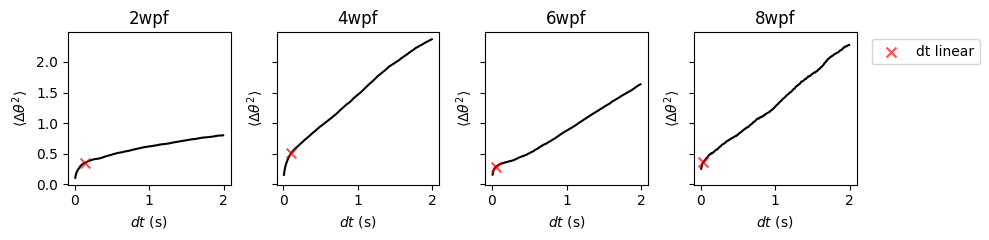

In [6]:
MSD_vs_t_all_ages = {age: [] for age in fish_ages}
for j,age in enumerate(fish_ages):
    dtheta_vs_t = np.concatenate(dtheta_vs_dt_all_ages[age], axis=0)
    MSD_vs_t, n_data_points = get_MSD_dtheta_vs_dt(dtheta_vs_t)
    MSD_vs_t_all_ages[age] = MSD_vs_t

dt_linear = np.zeros((len(fish_ages))) 
fig, ax = plt.subplots(1,4, figsize=(10,2.5), sharey='row', sharex='col')
for i, age in enumerate(fish_ages):  
    t = MSD_vs_t_all_ages[age][:,0]/fps
    y = MSD_vs_t_all_ages[age][:,1]

    first_derivative = np.gradient(y,t)
    second_derivative = np.gradient(first_derivative,t)

    ax[i].plot(t, y, color='k')
    ax[i].set_title(f'{age}wpf')

    # locate knee using first zero crossing of second derivative
    zero_crossings = np.where(np.diff(np.sign(second_derivative)))[0]
    if len(zero_crossings) > 0:
        ind = zero_crossings[0]
        ax[i].scatter(t[ind], y[ind], color='r',marker='x', s=50, label='dt linear',zorder=10, alpha=0.7)
        dt_linear[i] = t[ind]

    ax[i].set_ylabel(r'$\langle\Delta\theta^2\rangle$')
    ax[i].set_xlabel('$dt$ (s)')
ax[-1].legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=10)
fig.tight_layout()

### For self-consistency, the rate of diffusion events is upper bounded $s\leq1/dt_{\mathrm{linear}}$

In [7]:
s_max = 1/dt_linear

# Fit microscopic parameters $(s,\epsilon)$ for full dataset

In [8]:
microscopic_params_full_dataset = np.zeros((len(fish_ages), 4)) # columns: s, epsilon, beta, v

In [56]:
MSD_linear_fit_full_dataset = np.zeros((len(fish_ages), 2)) # columns: slope, intercept
for j, age in enumerate(fish_ages):
    MSD_slope, intercept = fit_MSD_curve_linear_regime(MSD_vs_t_all_ages[age], dt_linear[j])
    MSD_linear_fit_full_dataset[j] = [MSD_slope, intercept]
    s_eps_fit = fit_s_epsilon_jointly_bounded(alpha=mesoscopic_params_full_dataset[j,0], slope=MSD_slope, s_upper_bound=s_max[j])
    # velocity averaged over all experiments
    v  = np.nanmean(np.concatenate(v_values_all_ages[age], axis=0))

    microscopic_params_full_dataset[j,:] = [s_eps_fit[0], s_eps_fit[1], mesoscopic_params_full_dataset[j,1], v]

In [58]:
# write to file
np.savetxt(f'../../Results/microscopic_params_full_dataset.csv', microscopic_params_full_dataset, delimiter=',', header='s,epsilon,beta,v')

# Next, compute MSD and its slope for subsamples of experiments
- Sample size for subsampling experiments = N_exp/2 for each age [5,4,5,4 experiments respectively], and we consider all possible subsamples 
- We will use the same $dt_\mathrm{linear}$ as that for the full dataset


In [14]:
MSD_vs_t_all_ages_all_samples = {age: [] for age in fish_ages}
MSD_slope_and_v_all_ages_all_samples = {age: [] for age in fish_ages}   

for j,age in enumerate(fish_ages):
    N_exp = len(dtheta_vs_dt_all_ages[age])
    sample_size = np.ceil(N_exp/2)
    N_samples = int(comb(N_exp, sample_size))
    fit_results = np.empty((N_samples,2)) #sample, (slope, v_mean)
    
    for i,sample in enumerate(combinations(range(N_exp), int(sample_size))):
        dtheta_vs_t = np.concatenate([dtheta_vs_dt_all_ages[age][ind] for ind in sample], axis=0)
        # get sample MSD
        sample_MSD_vs_t, _ = get_MSD_dtheta_vs_dt(dtheta_vs_t)
        MSD_vs_t_all_ages_all_samples[age].append(sample_MSD_vs_t)
        # get slope
        sample_MSD_slope, _ = fit_MSD_curve_linear_regime(sample_MSD_vs_t, dt_linear[j])
        # get mean velocity
        v  = np.nanmean(np.concatenate([v_values_all_ages[age][ind] for ind in sample], axis=0))
        fit_results[i,:] = [sample_MSD_slope, v]
        if i % 20 == 0:
            print(f"{age} weeks, sample {i+1}/{N_samples} done")
    MSD_slope_and_v_all_ages_all_samples[age] = fit_results


2 weeks, sample 1/252 done
2 weeks, sample 21/252 done
2 weeks, sample 41/252 done
2 weeks, sample 61/252 done
2 weeks, sample 81/252 done
2 weeks, sample 101/252 done
2 weeks, sample 121/252 done
2 weeks, sample 141/252 done
2 weeks, sample 161/252 done
2 weeks, sample 181/252 done
2 weeks, sample 201/252 done
2 weeks, sample 221/252 done
2 weeks, sample 241/252 done
4 weeks, sample 1/35 done
4 weeks, sample 21/35 done
6 weeks, sample 1/126 done
6 weeks, sample 21/126 done
6 weeks, sample 41/126 done
6 weeks, sample 61/126 done
6 weeks, sample 81/126 done
6 weeks, sample 101/126 done
6 weeks, sample 121/126 done
8 weeks, sample 1/35 done
8 weeks, sample 21/35 done


#### Plot MSD curves for full dataset and subsamples (Fig. S4)

Text(0.5, -0.08, 'Time (s)')

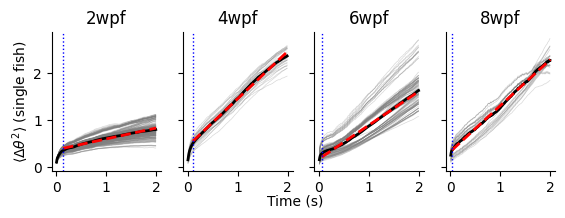

In [15]:
w = 6.5
h =1.8
title_size = 12
labelsize = 10
tick_size = 8
markersize= 20
t_max = 2 # s, for plot

fig,ax = plt.subplots(1,4,figsize=(w,h), sharey=True)
cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(4)]
for j,age in enumerate(fish_ages):
    # plot subsamples
    for i in range(len(MSD_vs_t_all_ages_all_samples[age])):
        MSD_vs_t = MSD_vs_t_all_ages_all_samples[age][i]
        ax[j].plot(MSD_vs_t[:,0]/fps, MSD_vs_t[:,1], color = 'gray', alpha=0.3, linewidth=0.5)
    # plot full dataset
    MSD_vs_t = MSD_vs_t_all_ages[age]
    ax[j].plot(MSD_vs_t[:,0]/fps, MSD_vs_t[:,1],  color = 'k', alpha=1, linewidth=2, label='Full dataset')

    # plot fitted line for full dataset
    slope = MSD_linear_fit_full_dataset[j, 0]
    intercept = MSD_linear_fit_full_dataset[j, 1]
    t_min = dt_linear[j] # min time for fitting slope of MSD
    ax[j].plot([t_min, t_max], [slope*t_min + intercept, slope*t_max+intercept], 'r--', linewidth=2)
    ax[j].axvline(t_min, color='b', linestyle=':', label='Fit start', linewidth=1)
    #ax[j].scatter(t_min, slope*t_min + intercept, color='b', marker='x', s=50, label='Fit start', zorder=10, alpha=1, linewidth=1)

    ax[j].set_title(f'{age}wpf', fontsize=title_size)
    
    if j == 0:
        ax[j].set_ylabel(r'$\langle\Delta\theta^2\rangle$ (single fish)', fontsize=labelsize, labelpad=1)
    ax[j].set_xticks([0,1,2])
    #ax[j].set_ylim([0,3])
    #ax[j].set_yticks([0,1,2,3])
    ax[j].tick_params(axis='both', which='major', labelsize=10)
    # turn off top and right spines
    ax[j].spines['top'].set_visible(False)
    ax[j].spines['right'].set_visible(False)
    #ax[j].set_xlim([0,t_max])

# add common x label
fig.text(0.5, -0.08, 'Time (s)', ha='center', fontsize=labelsize)


# Fit multivariate Gaussian distribution for microscopic parameters
Since $s,\epsilon$ are not independent due to $\alpha = s(1-\mathrm{exp}(-\epsilon/2))$, we will instead consider distribution of the set of microscopic parameters ($\alpha$, $\beta$, MSD slope, $v$)

In [59]:
# load alpha, beta fit results for subsamples
data = np.load('alpha_beta_fit_results_all_samples_avg_over_Ng.npz', allow_pickle=True)
alpha_beta_all_samples = data['alpha_beta_fit_results_all_samples_avg_over_Ng'].item()

# alpha, beta, slope, v for the full dataset
full_dataset_distribution_vars = np.column_stack([mesoscopic_params_full_dataset, MSD_linear_fit_full_dataset[:,0],microscopic_params_full_dataset[:,3] ])

## Plot params and fit distribution (Fig. S6)

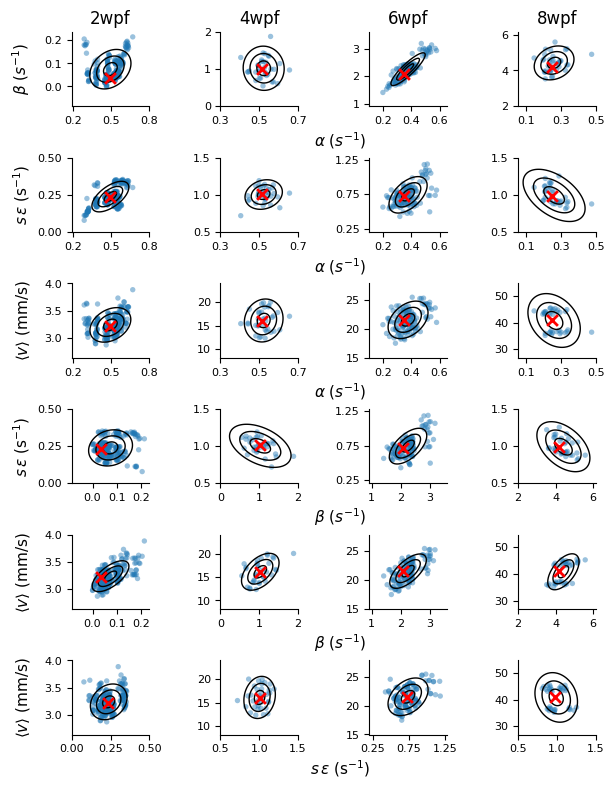

In [60]:
dist_params_mean_all_ages = []
dist_params_cov_all_ages = []
sampled_params_all_ages = []
labels = [r'$\alpha$ ($s^{-1}$)', r'$\beta$ ($s^{-1}$)', r'$s\,\varepsilon$ (s$^{-1}$)', r'$\langle v \rangle$ (mm/s)']

# limits for each parameter and each age
lims = [
    [[0.2,0.8], [-0.08,0.25], [0,0.5], [2.7,4]], # 2 weeks
    [[0.35,0.75], [0,2.5], [0.5,1.5], [10,22]], # 4 weeks
    [[0.15,0.6], [1,3.5], [0.25,1.25], [15,28]], # 6 weeks
    [[0.05,0.55], [2,7], [0.5,1.5], [30,55]], # 8 weeks
]

ticks = [
    [[0.2,0.5,0.8], [0,0.1,0.2], [0,0.25,0.5], [3,3.5, 4]], # 2 weeks
    [[0.3,0.5,0.7], [0,1,2], [0.5,1,1.5], [10,15,20]], # 4 weeks
    [[0.2,0.4,0.6], [1,2,3], [0.25,0.75,1.25], [15,20,25]], # 6 weeks
    [[0.1,0.3,0.5], [2,4,6], [0.5,1,1.5], [30,40,50]], # 8 weeks
]
w = 6.5
h = 8
labelsize = 11
ticksize = 8
title_size = 12

fig, ax = plt.subplots(6,4, figsize=(w, h))

for j,age in enumerate(fish_ages):
    alpha = alpha_beta_all_samples[age][:,0]
    beta = alpha_beta_all_samples[age][:,1]
    slope = MSD_slope_and_v_all_ages_all_samples[age][:,0]
    v = MSD_slope_and_v_all_ages_all_samples[age][:,1]
    data = np.column_stack((alpha, beta, slope, v))
    sampled_params_all_ages.append(data)
    mean = np.mean(data, axis=0)
    dist_params_mean_all_ages.append(mean)
    cov = np.cov(data, rowvar=False)
    dist_params_cov_all_ages.append(cov)

    c = 0 
    xlabels_list = []
    for i in range(4):
        for k in range(i+1, 4):
            ax[c,j].scatter(sampled_params_all_ages[j][:,i], sampled_params_all_ages[j][:,k], alpha=0.45, s=15, edgecolor='none', linewidth=0.25)
            ax[c,j].scatter(full_dataset_distribution_vars[j,i], full_dataset_distribution_vars[j,k], marker='x', color='r', label='Full dataset', s=60, alpha=1, linewidth=2,zorder=10)
            cov_reduced = cov[np.ix_([i,k],[i,k])]
            mean_reduced = mean[[i,k]]
            # plot a multivariate normal distribution
            x, y = np.mgrid[mean_reduced[0]-3.5*np.sqrt(cov_reduced[0,0]):mean_reduced[0]+3.5*np.sqrt(cov_reduced[0,0]):100j, 
                            mean_reduced[1]-3.5*np.sqrt(cov_reduced[1,1]):mean_reduced[1]+3.5*np.sqrt(cov_reduced[1,1]):100j]
            pos = np.dstack((x, y))
            rv = multivariate_normal(mean=mean_reduced, cov=cov_reduced)
            z = rv.pdf(pos)
            sigmas = np.sqrt(cov_reduced[np.diag_indices(2)])
            ax[c,j].contour(x, y, z, levels=rv.pdf([1.5*sigmas+mean_reduced, 1*sigmas+mean_reduced, 0.5*sigmas+mean_reduced]), colors='k', linewidths=1, alpha =1)
            if j==0:
                ax[c,j].set_ylabel(labels[k], fontsize=labelsize)
            if c==0:
                ax[c,j].set_title(f'{age}wpf', fontsize=title_size)
            ax[c,j].tick_params(axis='both', which='major', labelsize=ticksize)
            # turn off top and right spines
            ax[c,j].spines['top'].set_visible(False)
            ax[c,j].spines['right'].set_visible(False)
            xlabels_list.append(labels[i])
            #ax[c,j].set_xlim(lims[j][i])
            #ax[c,j].set_ylim(lims[j][k])
            ax[c,j].set_xticks(ticks[j][i])
            ax[c,j].set_yticks(ticks[j][k])
            c += 1


# common x labels
fig.align_ylabels()
fig.tight_layout(pad=2)
for i in range(6):
    # get position of the middle plot in each row
    pos = ax[i,0].get_position()
    fig.text(0.55, pos.y0 - 0.05, xlabels_list[i], ha='center', fontsize=labelsize)


    



## Write distribution parameters to file

In [61]:
dist_params_mean_array = np.array(dist_params_mean_all_ages)
dist_params_cov_array = np.array(dist_params_cov_all_ages)

np.savez('../../Results/parameter_distribution_from_subsamples.npz',
    parameter_names=['alpha', 'beta', 'MSD_slope', 'v'],
    agewise_mean=dist_params_mean_array,
    agewise_cov=dist_params_cov_array,
    s_upper_bounds=1/dt_linear # to extract s, epsilon from sampled parameters
)
